# Notebook: Clasificación HAM10000 con CoAtNet-0

## 1: Instalación de dependencias

In [ ]:
# Instalación definitiva y limpieza de conflictos
%pip install -q \
    "tensorflow[and-cuda]==2.16.1" \
    tf-keras==2.16.0 \
    keras-cv==0.9.0 \
    keras-cv-attention-models \
    pandas matplotlib scikit-learn ipywidgets seaborn \
    lime shap opencv-python \
    python-dotenv kaggle


# Borramos Keras 3 justo después por si TensorFlow lo ha vuelto a instalar
# %pip uninstall -y keras keras-core

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cargamos las variables de entorno del archivo .env
import os
from dotenv import load_dotenv

# Carga las variables del archivo .env al entorno del sistema
load_dotenv()

True

## 2: Configuración de la GPU y librerías

In [3]:
import os

# 1. Forzamos modo Legacy para CoAtNet
os.environ["TF_USE_LEGACY_KERAS"] = "1"
# 2. Quitamos el aviso de oneDNN (para que el log sea más limpio)
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

# 3. LE INDICAMOS A TENSORFLOW DÓNDE ESTÁN TUS LIBRERÍAS DE NVIDIA
# Buscamos las que instaló el comando [and-cuda] arriba
import site
for path in site.getsitepackages():
    nvidia_path = os.path.join(path, "nvidia/cudnn/lib")
    if os.path.exists(nvidia_path):
        os.environ["LD_LIBRARY_PATH"] = nvidia_path + ":" + os.environ.get("LD_LIBRARY_PATH", "")

# Añadimos la ruta del driver de Windows en WSL2
os.environ["LD_LIBRARY_PATH"] = "/usr/lib/wsl/lib:" + os.environ.get("LD_LIBRARY_PATH", "")

import tensorflow as tf

# Comprobación de la 3080 Ti
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"🔥 ¡CONSEGUIDO! GPU lista: {gpus[0]}")
else:
    print("❌ Seguimos sin ver la GPU. Mira el error de arriba.")

2026-04-29 19:42:34.943708: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-29 19:42:35.788828: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


🔥 ¡CONSEGUIDO! GPU lista: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


2026-04-29 19:42:37.053275: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-29 19:42:37.211955: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-29 19:42:37.212006: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


## 3: Descarga y extracción del Dataset

Nota: debes tener descargado unzip ``sudo apt update && sudo apt install unzip -y``

In [4]:
%%bash
# 1. Definir rutas relativas al proyecto
PROJECT_ROOT=$(pwd)
DATA_DIR="$PROJECT_ROOT/datasets/ham10000"
ZIP_FILE="$DATA_DIR/ham10000-preprocessed.zip"
WITNESS_DIR="$DATA_DIR/organized_ham10000"
META_FILE="$DATA_DIR/HAM10000_metadata.csv"


# 2. Crear la carpeta base si no existe
mkdir -p "$DATA_DIR"

# 3. Lógica para las IMÁGENES (Tu código original)
if [ -d "$WITNESS_DIR" ]; then
    echo "✅ Escenario A: Las carpetas de imágenes ya existen en $WITNESS_DIR. Saltando descarga."
elif [ -f "$ZIP_FILE" ]; then
    echo "📦 Escenario B: ZIP de imágenes encontrado pero no descomprimido. Extrayendo ahora..."
    unzip -q "$ZIP_FILE" -d "$DATA_DIR" && rm "$ZIP_FILE"
    echo "✅ Descompresión terminada y ZIP eliminado."
else
    echo "🌐 Escenario C: No hay imágenes. Iniciando descarga desde Kaggle..."
    curl -L -o "$ZIP_FILE" https://www.kaggle.com/api/v1/datasets/download/rayeedaabir/ham10000-preprocessed
    echo "🚚 Descarga de imágenes finalizada. Descomprimiendo..."
    unzip -q "$ZIP_FILE" -d "$DATA_DIR" && rm "$ZIP_FILE"
fi

# 4. Lógica para los METADATOS (Nueva sección)
if [ -f "$META_FILE" ]; then
    echo "✅ Metadatos encontrados en $META_FILE."
else
    echo "📊 Los metadatos no existen. Descargando HAM10000_metadata.csv desde el dataset original..."
    
    # Descargar solo el archivo CSV del dataset original de kmader
    # Usamos -p para indicar la carpeta de destino
    kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -f HAM10000_metadata.csv -p "$DATA_DIR"
    
    # Kaggle a veces descarga el archivo individual dentro de un .zip
    if [ -f "$DATA_DIR/HAM10000_metadata.csv.zip" ]; then
        unzip -o "$DATA_DIR/HAM10000_metadata.csv.zip" -d "$DATA_DIR"
        rm "$DATA_DIR/HAM10000_metadata.csv.zip"
    fi
    
    echo "✅ Metadatos listos."
fi

echo "🚀 Proceso completo. Imágenes y metadatos preparados en $DATA_DIR"

✅ Escenario A: Las carpetas de imágenes ya existen en /home/herraiz/proyectos/TFM/datasets/ham10000/organized_ham10000. Saltando descarga.
✅ Metadatos encontrados en /home/herraiz/proyectos/TFM/datasets/ham10000/HAM10000_metadata.csv.
��� Proceso completo. Imágenes y metadatos preparados en /home/herraiz/proyectos/TFM/datasets/ham10000


## 4: Preparación de datos (Carga desde directorios)

Primero creamos una función que nos permita traducir las etiquetas, para facilitar su lectura

In [5]:
# Parámetros de configuración
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_PATH = "datasets/ham10000/organized_ham10000"
META_PATH = "datasets/ham10000/HAM10000_metadata.csv"
AUTOTUNE = tf.data.AUTOTUNE

In [6]:
def get_class_name_es(input_data):
    """
    Traduce las categorías de HAM10000 al español.
    Soporta códigos cortos ('mel') y nombres largos ('Melanoma').
    """
    translations = {
        # Mapeo para nombres largos (los que tienes ahora)
        'actinic keratoses': 'Queratosis actínica',
        'basal cell carcinoma': 'Carcinoma basocelular',
        'benign keratosis': 'Queratosis benigna',
        'dermatofibroma': 'Dermatofibroma',
        'melanocytic nevi': 'Nevus melanocítico',
        'melanoma': 'Melanoma',
        'vascular lesions': 'Lesión vascular',
        
        # Mapeo para códigos cortos (por si acaso)
        'akiec': 'Queratosis actínica',
        'bcc': 'Carcinoma basocelular',
        'bkl': 'Queratosis benigna',
        'df': 'Dermatofibroma',
        'nv': 'Nevus melanocítico',
        'mel': 'Melanoma',
        'vasc': 'Lesión vascular'
    }
    
    def translate(name):
        # Limpiamos el texto: minúsculas y quitar espacios en los extremos
        clean_name = str(name).lower().strip()
        return translations.get(clean_name, name)

    # Si recibimos una lista
    if isinstance(input_data, list):
        return [translate(name) for name in input_data]
    
    # Si recibimos un solo nombre
    return translate(input_data)

Preparamos los metadatos

In [7]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Cargar metadatos
df = pd.read_csv(META_PATH)

# 2. Preprocesamiento de Metadatos
# Rellenar edades faltantes con la media
df['age'] = df['age'].fillna(df['age'].mean())

# Encoding: Sexo y Localización (Categorical) + Edad (Escalada)
encoder = OneHotEncoder(sparse_output=False)
cat_features = encoder.fit_transform(df[['sex', 'localization']])
scaler = StandardScaler()
num_features = scaler.fit_transform(df[['age']])

# Combinar todas las características numéricas en un solo array
meta_array = np.hstack([num_features, cat_features]).astype(np.float32)
df_meta_ready = pd.DataFrame(meta_array, index=df['image_id'])

# 3. Mapeo de rutas de archivos
# Buscamos todas las imágenes .jpg en las subcarpetas
all_image_paths = []
all_labels = []
all_meta = []

class_names = sorted(os.listdir(DATA_PATH))  

# Mapeo inverso: Nombre de carpeta -> ID numérico (basado en el orden de class_names)
# 'class_names' viene de tu carpeta: ['Actinic Keratoses', 'Basal Cell Carcinoma', ...]
folder_to_id = {name: i for i, name in enumerate(class_names)}

for folder in class_names:
    folder_path = os.path.join(DATA_PATH, folder)
    for img_name in os.listdir(folder_path):
        if img_name.endswith('.jpg'):
            img_id = img_name.replace('.jpg', '')
            if img_id in df_meta_ready.index:
                all_image_paths.append(os.path.join(folder_path, img_name))
                all_labels.append(folder_to_id[folder])
                all_meta.append(df_meta_ready.loc[img_id].values)

# 4. Split de entrenamiento y validación (Stratified para mantener proporciones)
train_paths, val_paths, train_meta, val_meta, train_labels, val_labels = train_test_split(
    all_image_paths, all_meta, all_labels, test_size=0.2, random_state=123, stratify=all_labels
)
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           10015 non-null  float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB
None


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


Creamos la función que leerá tanto la imagen como los metadatos

In [8]:
def process_data(image_path, metadata, label):
    # Procesar imagen
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    
    # El modelo esperará un diccionario o una tupla de entradas: (imagen, metadatos)
    return (img, metadata), tf.one_hot(label, depth=7)

# Dataset de Entrenamiento
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_meta, train_labels))
train_ds = train_ds.shuffle(len(train_paths))
train_ds = train_ds.map(process_data, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Dataset de Validación
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_meta, val_labels))
val_ds = val_ds.map(process_data, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

class_names_es = get_class_name_es(class_names)

print(f"✅ Clases detectadas (IDs): {class_names}")
print(f"🇪🇸 Traducción: {class_names_es}")


# Optimización para la GPU (Crucial para no tener cuellos de botella)
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

✅ Clases detectadas (IDs): ['Actinic Keratoses', 'Basal Cell Carcinoma', 'Benign Keratosis', 'Dermatofibroma', 'Melanocytic Nevi', 'Melanoma', 'Vascular Lesions']
🇪🇸 Traducción: ['Queratosis actínica', 'Carcinoma basocelular', 'Queratosis benigna', 'Dermatofibroma', 'Nevus melanocítico', 'Melanoma', 'Lesión vascular']


2026-04-29 19:42:37.799786: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-29 19:42:37.799866: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-29 19:42:37.799895: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-29 19:42:37.964984: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-29 19:42:37.965045: I external/local_xla/xla/stream_executor

## 5: Visualización de muestras

📸 Generando galería de presentación (un ejemplo por clase)...


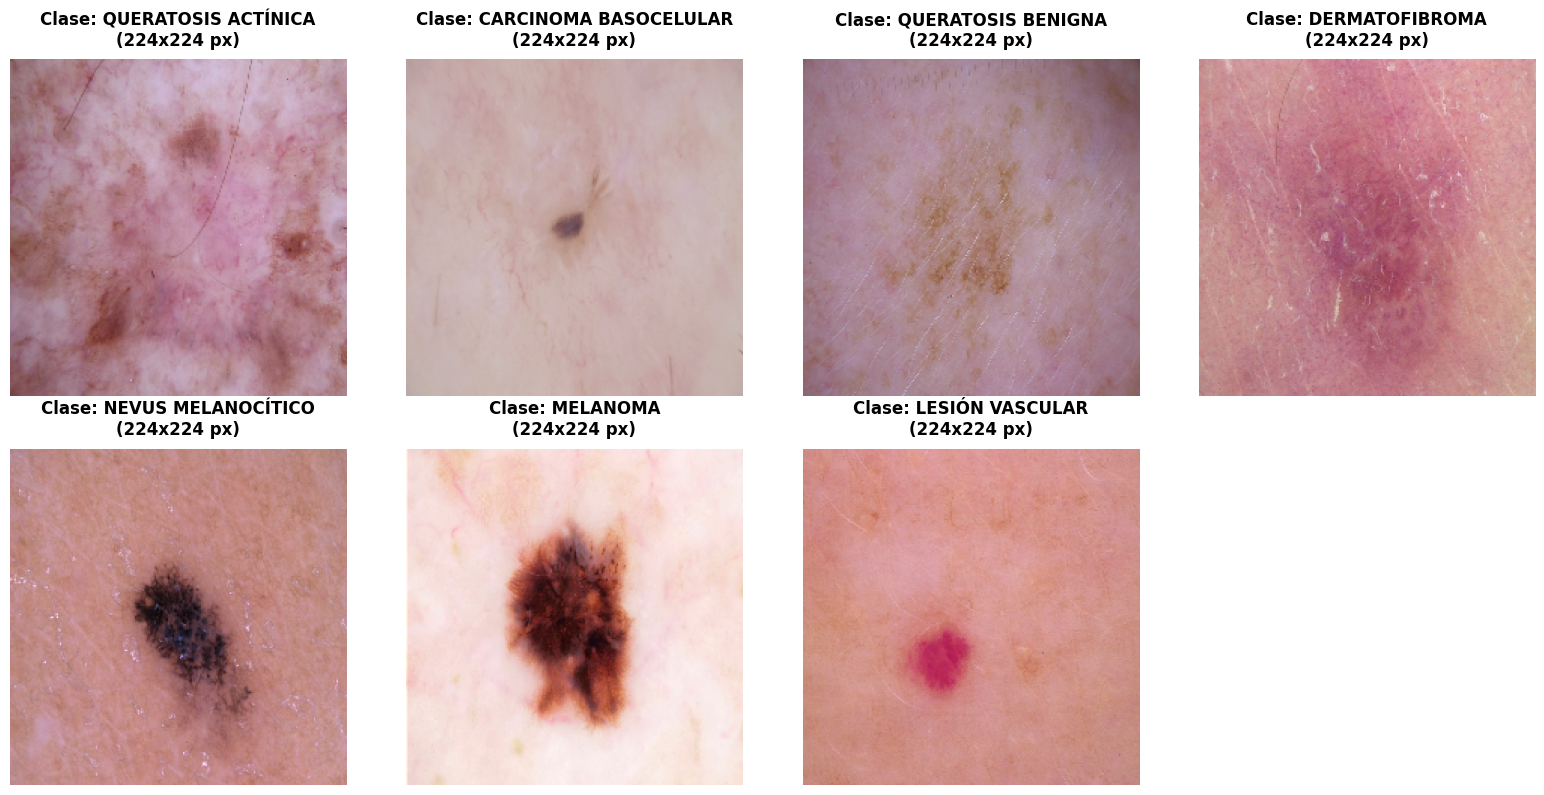

In [9]:
import matplotlib.pyplot as plt

# Configuración de la galería
plt.figure(figsize=(16, 8))
cols = 4
rows = (len(class_names) + cols - 1) // cols

print("📸 Generando galería de presentación (un ejemplo por clase)...")

for i, class_name in enumerate(sorted(class_names)):
    # Ruta a la carpeta de la clase
    class_path = os.path.join(DATA_PATH, class_name)
    # Tomamos la primera imagen que encontremos
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)
    
    # Cargar y procesar imagen para mostrar
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img).astype("uint8")
    
    ax = plt.subplot(rows, cols, i + 1)
    plt.imshow(img_array)
    
    # Título elegante con Nombre y Resolución
    plt.title(f"Clase: {get_class_name_es(class_name).upper()}\n({IMG_SIZE[0]}x{IMG_SIZE[1]} px)", 
              fontsize=12, fontweight='bold', pad=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

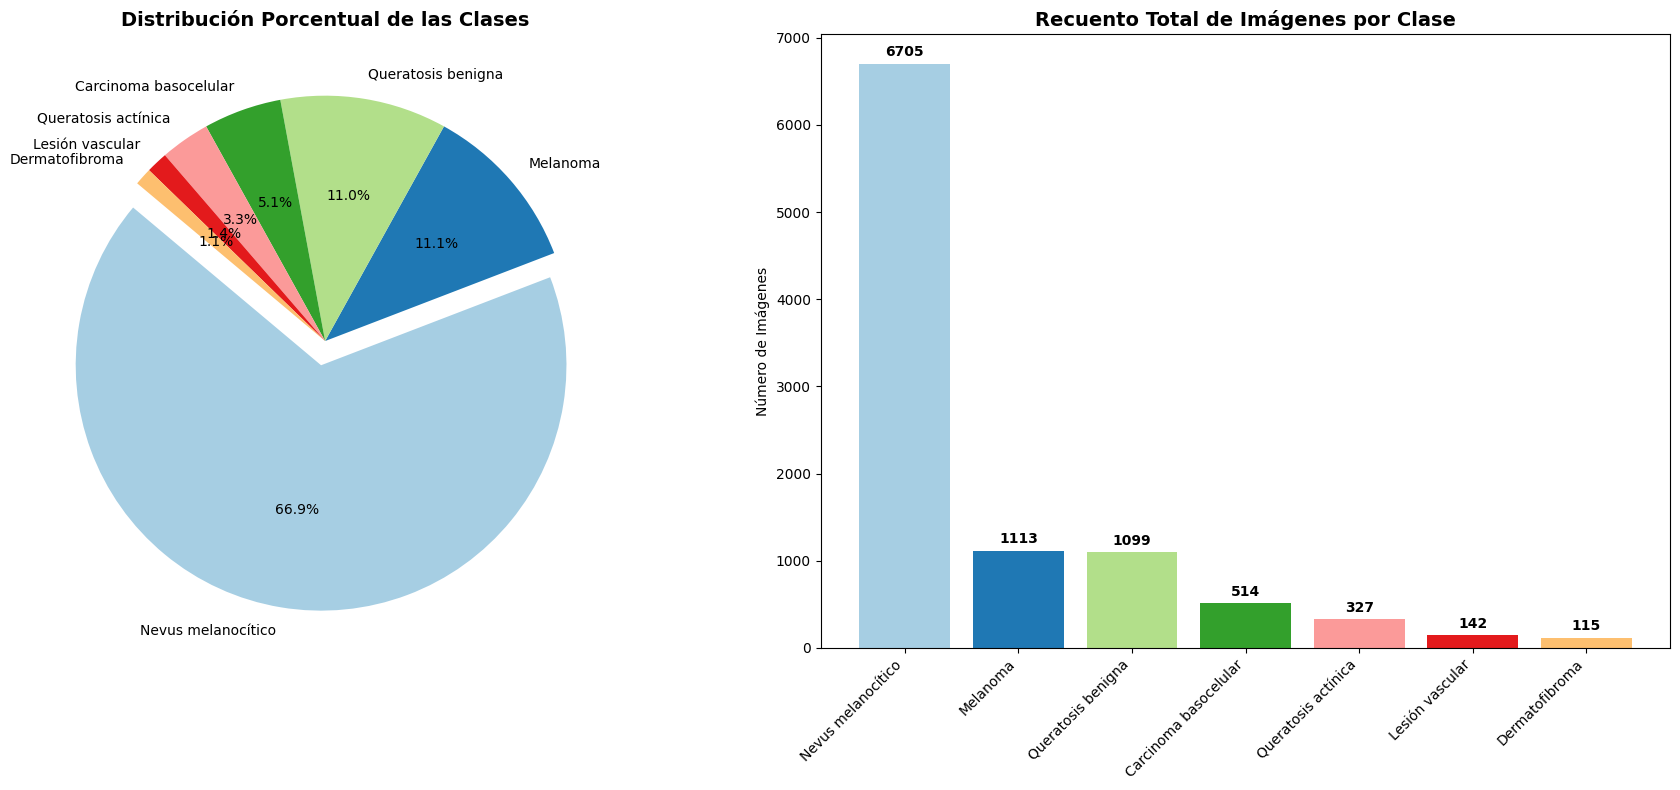


📋 Resumen Estadístico del Dataset (en español):
                 Tipo  Cantidad  Porcentaje
   Nevus melanocítico      6705       66.95
             Melanoma      1113       11.11
   Queratosis benigna      1099       10.97
Carcinoma basocelular       514        5.13
  Queratosis actínica       327        3.27
      Lesión vascular       142        1.42
       Dermatofibroma       115        1.15


In [10]:
# 1. Contar archivos por carpeta
stats = {}
for class_name in class_names:
    class_path = os.path.join(DATA_PATH, class_name)
    stats[class_name] = len(os.listdir(class_path))

# 2. Crear DataFrame y TRADUCIR
df_stats = pd.DataFrame(list(stats.items()), columns=['Tipo', 'Cantidad'])

# --- APLICAMOS LA TRADUCCIÓN AQUÍ ---
df_stats['Tipo'] = df_stats['Tipo'].apply(get_class_name_es)
# ------------------------------------

df_stats = df_stats.sort_values(by='Cantidad', ascending=False)
df_stats['Porcentaje'] = (df_stats['Cantidad'] / df_stats['Cantidad'].sum() * 100).round(2)

# 3. Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8)) # Aumentado un poco el alto

# Gráfico de Tarta
colors = plt.cm.Paired(range(len(class_names)))
wedges, texts, autotexts = ax1.pie(df_stats['Cantidad'], labels=df_stats['Tipo'], 
                                   autopct='%1.1f%%', startangle=140, colors=colors,
                                   explode=[0.1 if i == 0 else 0 for i in range(len(df_stats))])
ax1.set_title("Distribución Porcentual de las Clases", fontsize=14, fontweight='bold')

# Gráfico de Barras
bars = ax2.bar(df_stats['Tipo'], df_stats['Cantidad'], color=colors)
ax2.set_title("Recuento Total de Imágenes por Clase", fontsize=14, fontweight='bold')
ax2.set_ylabel("Número de Imágenes")

# Rotar etiquetas para que no se solapen los nombres en español
plt.sca(ax2)
plt.xticks(rotation=45, ha='right')

# Añadir etiquetas de cantidad sobre las barras
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Mostrar tabla resumen
print("\n📋 Resumen Estadístico del Dataset (en español):")
print(df_stats.to_string(index=False))

## 6: Pipeline de entrenamiento con CoAtNet-0

In [11]:
from keras_cv_attention_models import coatnet

def build_hybrid_coatnet(img_shape=(224, 224, 3), meta_shape=(train_meta[0].shape[0],)):
    # --- RAMA 1: Imágenes ---
    img_input = tf.keras.Input(shape=img_shape, name="image_input")
    
    # Base de CoAtNet
    base_model = coatnet.CoAtNet0(input_shape=img_shape, num_classes=0, pretrained="imagenet")
    x_img = base_model(img_input) 
    
    # SOLUCIÓN: Convertir (7, 7, 768) en (768)
    x_img = tf.keras.layers.GlobalAveragePooling2D()(x_img)
    
    # --- RAMA 2: Metadatos ---
    meta_input = tf.keras.Input(shape=meta_shape, name="meta_input")
    x_meta = tf.keras.layers.Dense(32, activation='relu')(meta_input)
    x_meta = tf.keras.layers.Dense(16, activation='relu')(x_meta)
    
    # --- CONCATENACIÓN ---
    # Ahora ambos son vectores: (None, 768) + (None, 16) = (None, 784)
    combined = tf.keras.layers.Concatenate()([x_img, x_meta])
    
    # --- CABEZA FINAL ---
    x = tf.keras.layers.Dense(256, activation='relu')(combined)
    x = tf.keras.layers.Dropout(0.3)(x)
    output = tf.keras.layers.Dense(7, activation='softmax')(x)
    
    model = tf.keras.Model(inputs=[img_input, meta_input], outputs=output)
    return model

model = build_hybrid_coatnet()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
print("✅ Modelo CoAtNet-0 cargado y compilado con éxito.")
# model.summary()

>>>> Load pretrained from: /home/herraiz/.keras/models/coatnet0_224_imagenet.h5
✅ Modelo CoAtNet-0 cargado y compilado con éxito.


## 7: Entrenamiento (Prueba rápida)

In [ ]:
# --- CONFIGURACIÓN DE FLUJO ---
SKIP_TRAINING = True  # True: Carga el modelo si existe | False: Entrena de cero
checkpoint_path = "models/best_coatnet_v1.h5"

# 1. Lógica de Entrenamiento / Carga
model_exists = os.path.exists(checkpoint_path)
should_train = True

if SKIP_TRAINING and model_exists:
    print(f"📦 Cargando modelo guardado desde: {checkpoint_path}")
    model.load_weights(checkpoint_path)
    should_train = False
    history = None
else:
    if SKIP_TRAINING and not model_exists:
        print("⚠️ Aviso: SKIP_TRAINING es True pero no hay modelo. Entrenando...")
    else:
        print("🔥 Iniciando entrenamiento en la RTX 3080 Ti...")
    
    os.makedirs("models", exist_ok=True)
    checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        callbacks=[checkpoint_callback]
    )

# 2. PREDICCIONES DE ENTRENAMIENTO (Lo que estaba en la Celda 11)
# Esto se ejecuta siempre para tener las variables listas para las gráficas
print("\n🏋️ Generando predicciones sobre el set de ENTRENAMIENTO...")
y_true_train = []
y_pred_train = []

# Ahora desempaquetamos (inputs, labels) donde inputs es (images, meta)
for (images, meta), labels in train_ds:
    # Pasamos ambos inputs al modelo
    predictions = model.predict((images, meta), verbose=0)
    
    y_true_train.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_train.extend(np.argmax(predictions, axis=1))


y_true_train = np.array(y_true_train)
y_pred_train = np.array(y_pred_train)

print(f"✅ Análisis de entrenamiento completado ({len(y_true_train)} imágenes).")

📦 Cargando modelo guardado desde: models/best_coatnet_v1.h5

🏋️ Generando predicciones sobre el set de ENTRENAMIENTO...


2026-04-29 19:42:55.919180: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


✅ Análisis de entrenamiento completado (8012 imágenes).


2026-04-29 19:43:24.321046: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 8: Predicciones (Preparación de datos)
En esta celda extraemos las etiquetas reales y generamos las predicciones del modelo sobre el set de validación.

In [13]:
print("🔮 Generando predicciones sobre el set de VALIDACIÓN...")

y_true_val = []
y_pred_val = []

for (images, meta), labels in val_ds:
    predictions = model.predict((images, meta), verbose=0)
    
    # Guardamos etiquetas reales y predicciones del modelo
    y_true_val.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_val.extend(np.argmax(predictions, axis=1))

y_true_val = np.array(y_true_val)
y_pred_val = np.array(y_pred_val)

print(f"✅ Análisis de validación completado ({len(y_true_val)} imágenes).")

🔮 Generando predicciones sobre el set de VALIDACIÓN...
✅ Análisis de validación completado (2003 imágenes).


2026-04-29 19:43:31.245851: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 9: Métricas Globales y por Clase

Aquí verás el rendimiento del entrenamiento (si lo hubo) y el reporte detallado (Precisión, Recall, F1-Score) por cada tipo de lesión.

In [14]:
from sklearn.metrics import classification_report, accuracy_score

# 1. Accuracy Global
acc_train = accuracy_score(y_true_train, y_pred_train)
acc_val = accuracy_score(y_true_val, y_pred_val)

print("="*60)
print(f"📈 RENDIMIENTO GLOBAL (Modelo Híbrido)")
print(f"   - Accuracy Entrenamiento: {acc_train:.4f}")
print(f"   - Accuracy Validación:    {acc_val:.4f}")
print("="*60)

# 2. Reporte Detallado de Validación
print("\n📋 REPORTE DETALLADO POR CLASE (SET DE VALIDACIÓN):")
print(classification_report(y_true_val, y_pred_val, target_names=class_names_es))

# 3. Reporte Detallado de Entrenamiento
print("\n📋 REPORTE DETALLADO POR CLASE (SET DE ENTRENAMIENTO):")
print(classification_report(y_true_train, y_pred_train, target_names=class_names_es))

📈 RENDIMIENTO GLOBAL (Modelo Híbrido)
   - Accuracy Entrenamiento: 0.9764
   - Accuracy Validación:    0.8792

📋 REPORTE DETALLADO POR CLASE (SET DE VALIDACIÓN):
                       precision    recall  f1-score   support

  Queratosis actínica       0.76      0.74      0.75        65
Carcinoma basocelular       0.79      0.86      0.82       103
   Queratosis benigna       0.78      0.71      0.74       220
       Dermatofibroma       0.58      0.78      0.67        23
   Nevus melanocítico       0.93      0.96      0.94      1341
             Melanoma       0.76      0.63      0.69       223
      Lesión vascular       1.00      0.79      0.88        28

             accuracy                           0.88      2003
            macro avg       0.80      0.78      0.78      2003
         weighted avg       0.88      0.88      0.88      2003


📋 REPORTE DETALLADO POR CLASE (SET DE ENTRENAMIENTO):
                       precision    recall  f1-score   support

  Queratosis actínica  

## 10: Matriz de Confusión

Esta es la gráfica visual definitiva para ver dónde se "equivoca" el modelo (por ejemplo, si confunde Melanoma con Nevus).

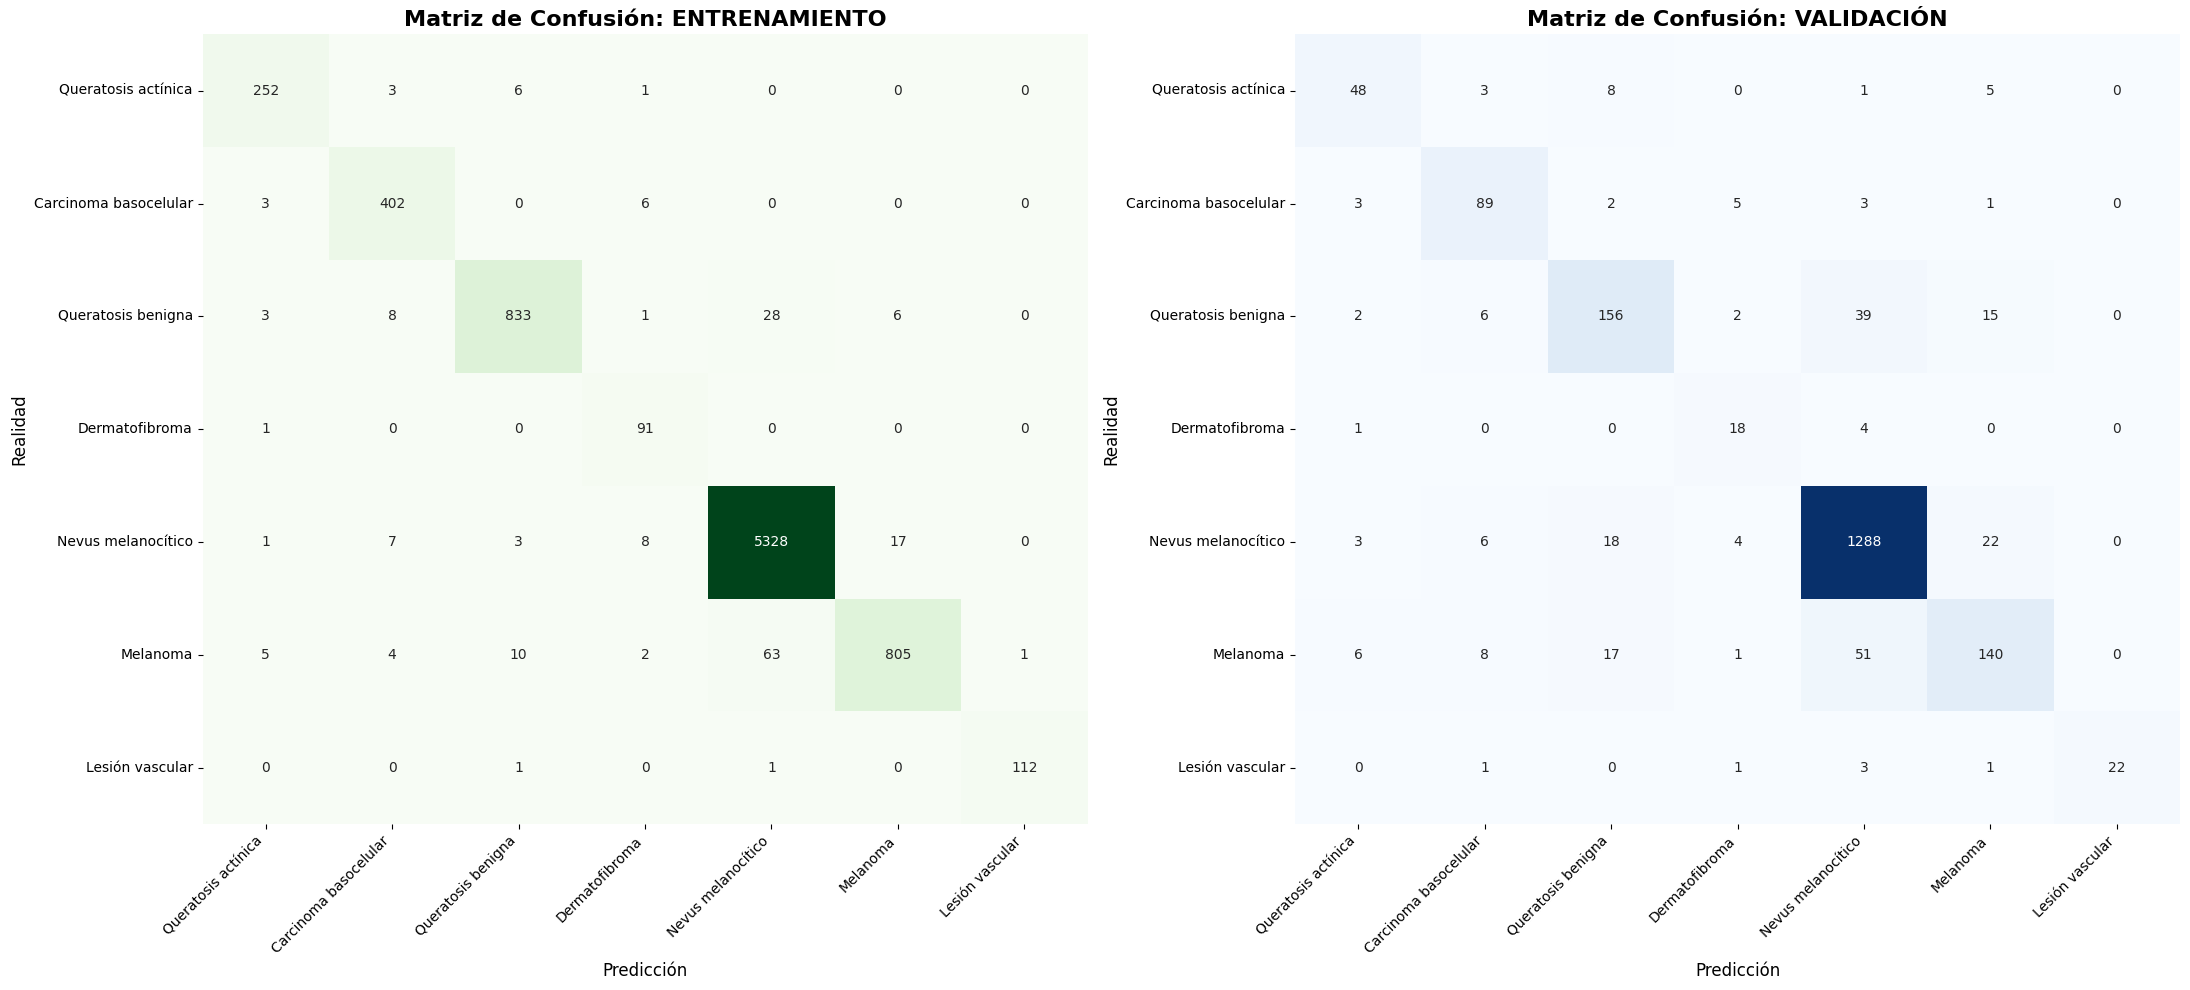

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculamos las matrices (la lógica sigue igual)
cm_train = confusion_matrix(y_true_train, y_pred_train)
cm_val = confusion_matrix(y_true_val, y_pred_val)

# 2. Configuramos el gráfico
fig, ax = plt.subplots(1, 2, figsize=(22, 10)) # Aumentamos un poco el tamaño

# Matriz de Entrenamiento (Verde)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', ax=ax[0],
            xticklabels=class_names_es, yticklabels=class_names_es,
            cbar=False) # Quitamos la barra lateral para ganar espacio
ax[0].set_title('Matriz de Confusión: ENTRENAMIENTO', fontsize=16, fontweight='bold')
ax[0].set_xlabel('Predicción', fontsize=12)
ax[0].set_ylabel('Realidad', fontsize=12)

# Matriz de Validación (Azul)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=ax[1],
            xticklabels=class_names_es, yticklabels=class_names_es,
            cbar=False)
ax[1].set_title('Matriz de Confusión: VALIDACIÓN', fontsize=16, fontweight='bold')
ax[1].set_xlabel('Predicción', fontsize=12)
ax[1].set_ylabel('Realidad', fontsize=12)

# --- AJUSTE CRÍTICO DE ETIQUETAS ---
# Rotamos las etiquetas de las X para que no se pisen
for a in ax:
    plt.sca(a)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 11: Inteligencia Artificial Explicable (XAI) - Grad-CAM
En esta sección visualizamos en qué regiones de la imagen se fija el modelo CoAtNet para clasificar las lesiones.

📊 Generando comparativa XAI (Grad-CAM, LIME, SHAP) para el modelo híbrido...


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

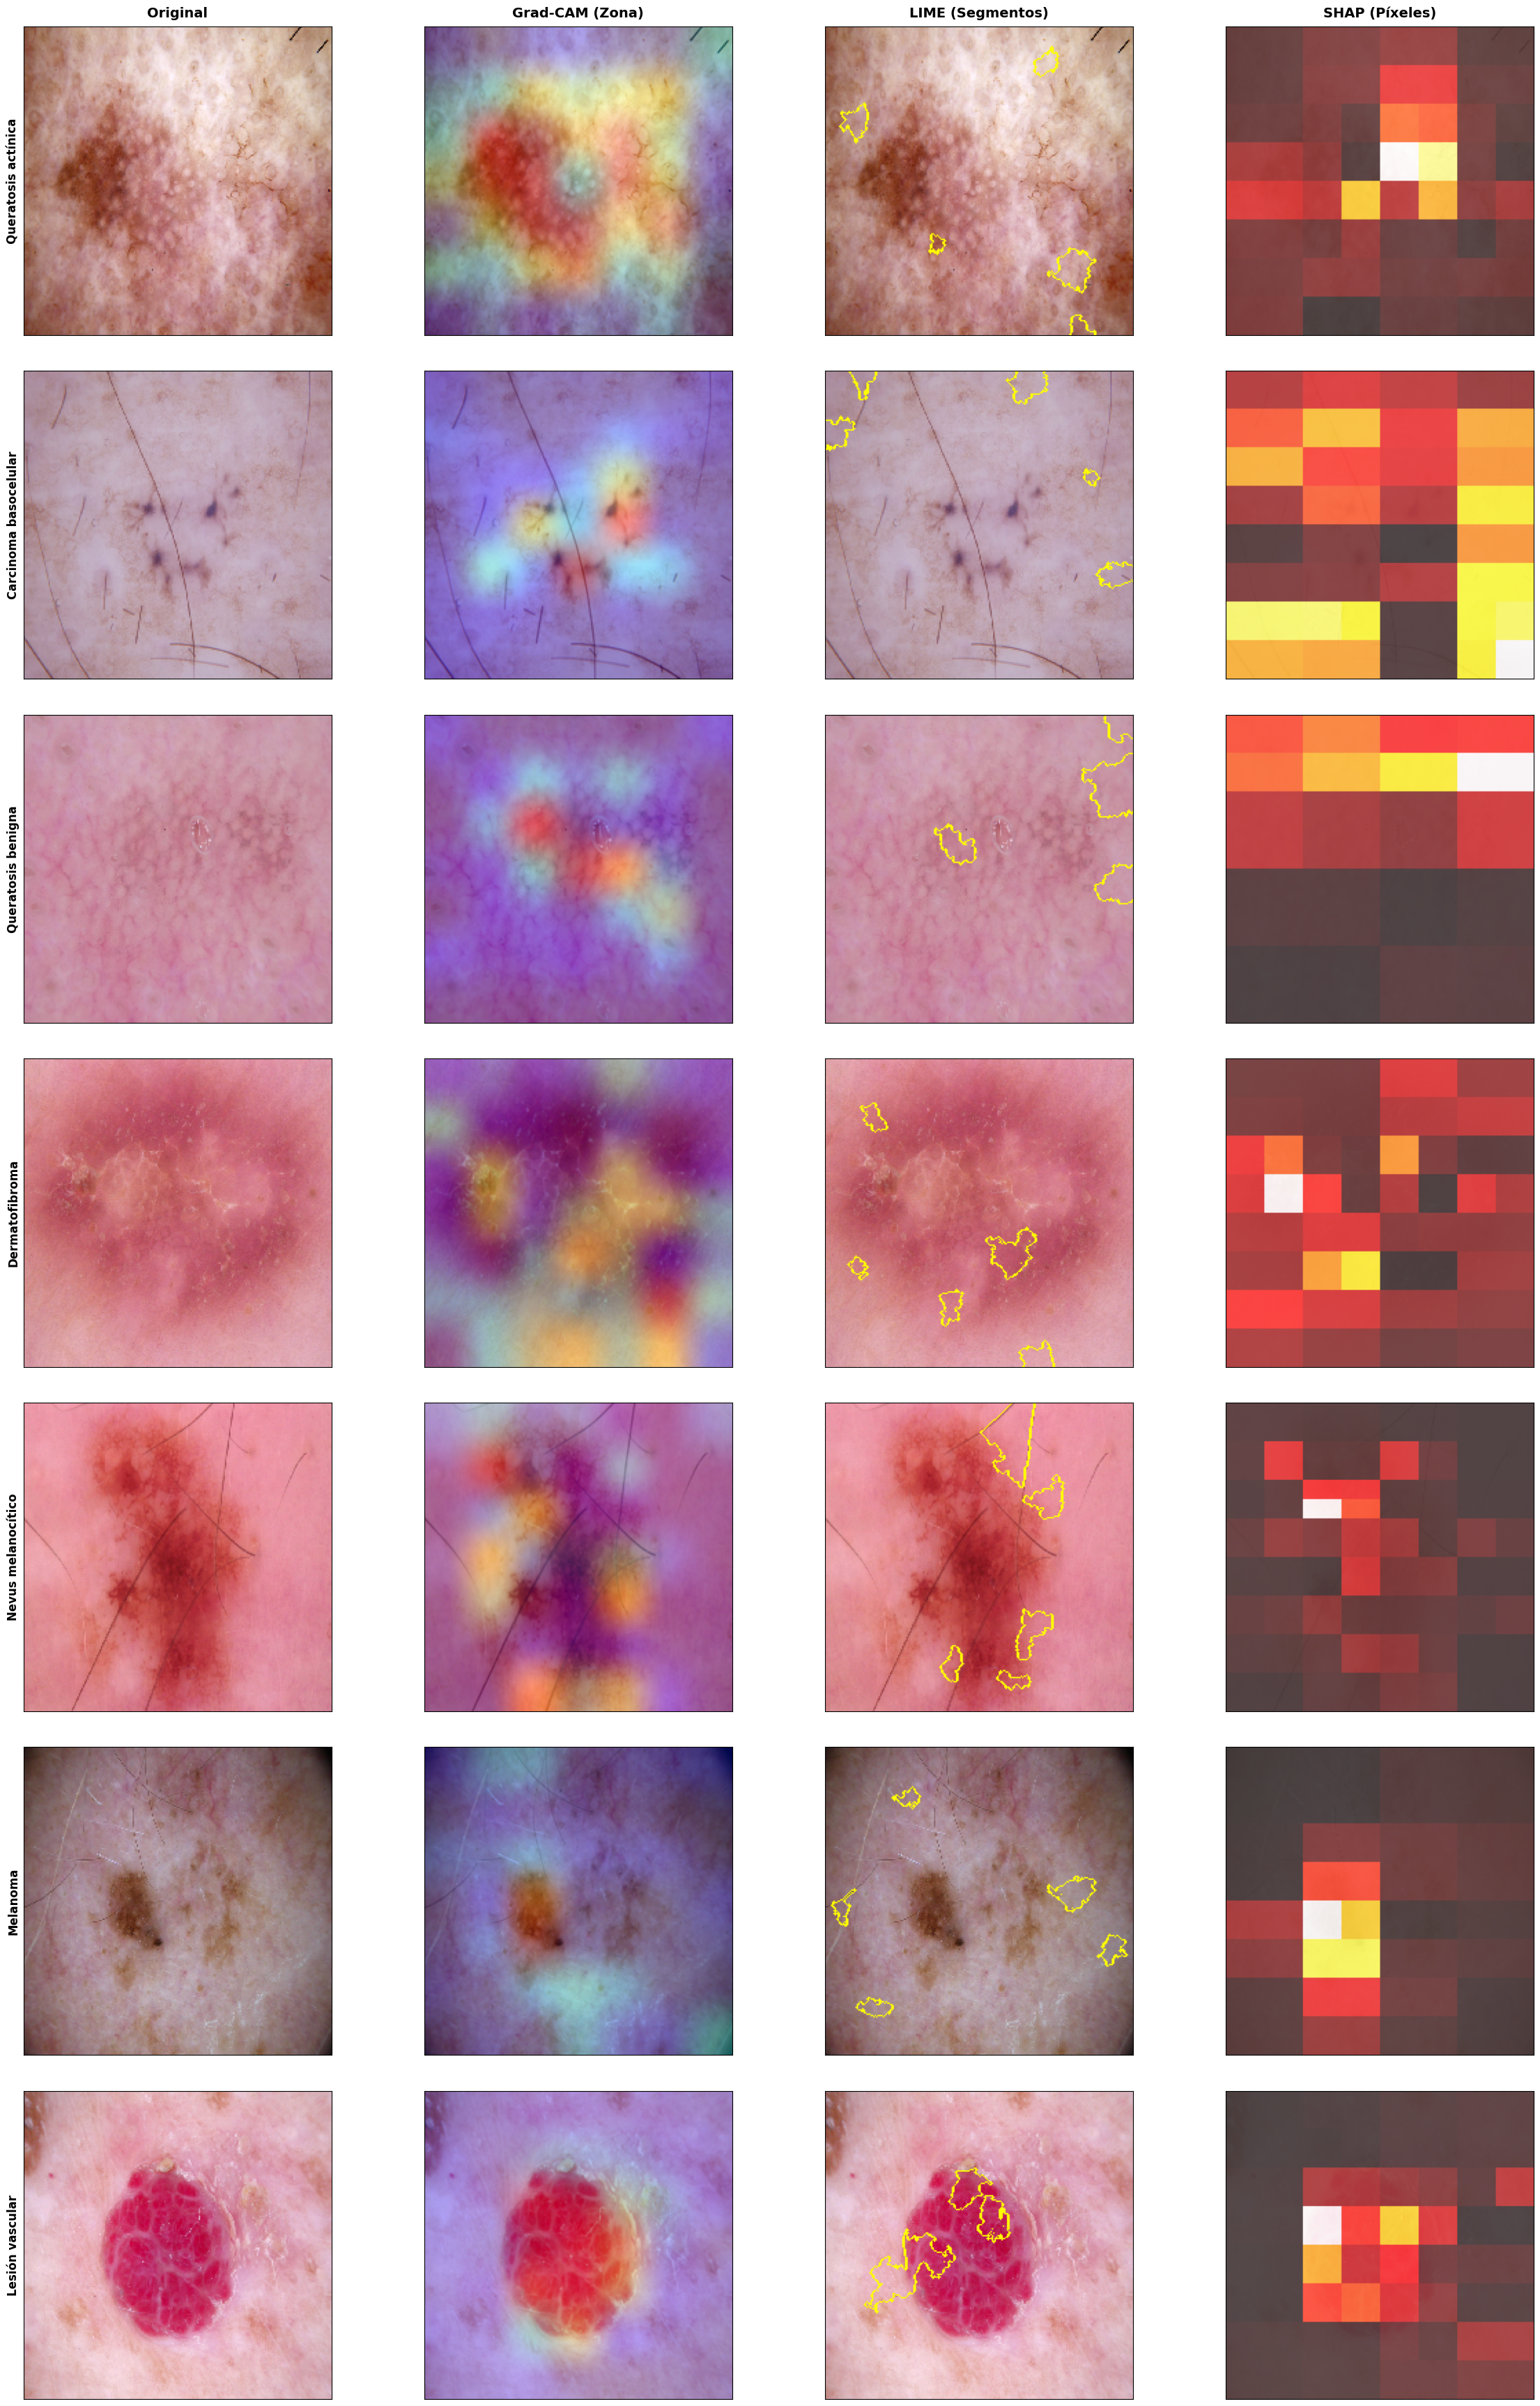

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
import random
import contextlib
import tensorflow as tf
import shap
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries, quickshift

# --- 1. FUNCIONES CORE ADAPTADAS ---

def get_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index):
    """
    Genera Grad-CAM para modelos híbridos atacando directamente al backbone de visión.
    """
    # Accedemos al sub-modelo de visión (la caja de CoAtNet)
    v_model = model.get_layer('coatnet0')
    
    # Creamos un modelo que mapee desde la entrada de visión a la capa conv y la salida de visión
    grad_model = tf.keras.models.Model(
        [v_model.inputs], 
        [v_model.get_layer(last_conv_layer_name).output, v_model.output]
    )

    with tf.GradientTape() as tape:
        # Aquí solo pasamos la imagen al sub-modelo
        conv_output, vision_preds = grad_model(img_array)
        # Usamos el índice que predijo el modelo COMPLETO
        class_channel = vision_preds[:, pred_index]

    # Gradientes y pesos
    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    heatmap = conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def superimpose_heatmap(img_path, heatmap, alpha=0.4):
    img = tf.keras.utils.load_img(img_path)
    img_arr = tf.keras.utils.img_to_array(img)
    heatmap_arr = np.uint8(255 * heatmap)
    jet = plt.get_cmap("jet")(np.arange(256))[:, :3]
    jet_heatmap = tf.keras.utils.array_to_img(jet[heatmap_arr]).resize((img_arr.shape[1], img_arr.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)
    return tf.keras.utils.array_to_img(jet_heatmap * alpha + img_arr)

# --- 2. CONFIGURACIÓN Y BUCLE PRINCIPAL ---

print("📊 Generando comparativa XAI (Grad-CAM, LIME, SHAP) para el modelo híbrido...")

# Identificar capa convolucional dentro del sub-modelo
sub_model = model.get_layer('coatnet0')
last_conv_name = [l.name for l in sub_model.layers if 'conv' in l.name.lower()][-1]
explainer_lime = lime_image.LimeImageExplainer()

n_clases = len(class_names)
fig, axes = plt.subplots(nrows=n_clases, ncols=4, figsize=(22, 5 * n_clases))
col_titles = ['Original', 'Grad-CAM (Zona)', 'LIME (Segmentos)', 'SHAP (Píxeles)']

# Silenciamos la verbosidad de SHAP y LIME
with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
    for i, nombre_clase in enumerate(class_names):
        # A. Selección de imagen y metadatos
        class_dir = os.path.join(DATA_PATH, nombre_clase)
        img_name = random.choice(os.listdir(class_dir))
        img_path = os.path.join(class_dir, img_name)
        img_id = img_name.replace('.jpg', '')
        
        # Extraer metadatos reales de esa imagen específica
        current_meta = df_meta_ready.loc[[img_id]].values.astype('float32')
        
        # B. Preparación de imagen
        img_raw = tf.keras.utils.load_img(img_path, target_size=(224, 224))
        img_array = tf.keras.utils.img_to_array(img_raw)
        img_input = np.expand_dims(img_array, axis=0) / 255.0

        # C. WRAPPER PARA LIME/SHAP (Inyecta metadatos fijos en cada batch de perturbaciones)
        def hybrid_predict(batch):
            m_batch = np.repeat(current_meta, batch.shape[0], axis=0)
            return model.predict([batch, m_batch], verbose=0)

        # 1. Ejecutar Predicción del modelo completo
        full_pred = model.predict([img_input, current_meta], verbose=0)
        pred_idx = np.argmax(full_pred[0])

        # 2. Grad-CAM
        h_map = get_gradcam_heatmap(img_input, model, last_conv_name, pred_idx)
        gcam_res = superimpose_heatmap(img_path, h_map).resize((224, 224))
        
        # 3. LIME
        exp = explainer_lime.explain_instance(
            img_input[0].astype('double'), hybrid_predict, 
            top_labels=1, num_samples=500,
            segmentation_fn=lambda x: quickshift(x, kernel_size=3, max_dist=6, ratio=0.5)
        )
        temp, mask = exp.get_image_and_mask(exp.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
        
        # 4. SHAP
        masker = shap.maskers.Image("blur(16,16)", shape=(224, 224, 3))
        expl_shap = shap.Explainer(hybrid_predict, masker, output_names=class_names_es)
        sv = expl_shap(img_input, max_evals=200, batch_size=50)
        abs_s = np.abs(sv.values[0, :, :, :, pred_idx]).sum(axis=-1)

        # --- RENDERIZADO ---
        
        # Original
        axes[i, 0].imshow(img_raw)
        axes[i, 0].set_ylabel(class_names_es[i], fontsize=12, fontweight='bold')
        
        # Grad-CAM
        axes[i, 1].imshow(gcam_res)
        
        # LIME
        axes[i, 2].imshow(mark_boundaries(temp, mask))
        
        # SHAP
        axes[i, 3].imshow(img_raw, alpha=0.3)
        axes[i, 3].imshow(abs_s, cmap='hot', alpha=0.7)

        # Limpiar ejes y poner títulos en la primera fila
        for j in range(4):
            axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
            if i == 0: axes[i, j].set_title(col_titles[j], fontweight='bold', fontsize=14, pad=10)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()